# Первая нейронная сеть на Keras


## Что такое Keras

Keras появился относительно недавно - в 2015 г. Но за это время стал одним из самых популярных фреймворков для создания нейросетей и фактически стандартом для использования его начинающими.

В чем причина его популярности? Keras позволяет создавать на высоком уровне абстракции. Т.е. не нужно вручную реализовать с помощью математикаподобного кода те или иные элементы нейронной сети. Мы можем оперировать слоями, количеством нейронов в них, выбором функции активации и т.д. В то же время keras содержит инструментарий для всего того, что может понадобиться для работы - например ряд встроенных датасетов, возможность обрабатывать изображения.

В техническом плане Keras это оболочка над инструментами меньшей степени абстракции. На выбор он может работать поверх TensorFlow, Microsoft Cognitive Toolkit, Theano.

Keras как и любой высокоабстрактный инструмент имеет изъяны в качестве меньшей гибкости и производительности, чем тот же tensorflow.





И сегодня обучим три нейронные сети для решения задач:
1. Нейрон для умножения
2. Нейросеть для сложения
3. Нейросеть для классификации изображений

Давайте создадим нейронную сеть, состоящую из одного нейрона.


<img src='https://drive.google.com/uc?id=1Qx71h2FmXS6uKHmhcIKtp49G5nqMncWK'>

- `Sequential` - это класс последовательности слоев в нейронной сети, у нас пока будет только один слой, но сюда можно добавлять сколь угодно слоев и это будет сеть, состоящая из последовательности слоев.
- `Dense` - это класс полносвязного/линейного слоя, все нейроны связаны друг с другом.
- `units=1` - это количество нейронов в слое. У нас 1 нейрон.
- `input_shape=(1,)` - это входная размерность объекта. У нас только 1 вход.
- `activation='relu'` - это функция активации, которая добавляет в слой нелинейности, именно из-за неё мы можем получать более сложные результаты работы сети.

In [1]:
from keras.layers import Dense
from keras.models import Sequential

model = Sequential([
    Dense(1, input_shape=(1,), activation='relu')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [2]:
model.get_weights()

[array([[-0.99692285]], dtype=float32), array([0.], dtype=float32)]

Инициализация весов всегда разная, если её не зафиксировать:



```
# for reproducible weights initialization
import tensorflow as tf
tf.random.set_seed(1)
```



In [3]:
import tensorflow as tf
tf.random.set_seed(1)

model = Sequential([
    Dense(1, input_shape=(1,), activation='relu')
])

model.get_weights()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


[array([[1.0855249]], dtype=float32), array([0.], dtype=float32)]

## Нейрон для умножения на 3

Создадим обучающие данные

In [4]:
import numpy as np

X = np.array([[1], [3], [2], [10], [4], [7], [8]])
y = np.array([[3, 9, 6, 30, 12, 21, 24]]).T

Для того, что обучить нейронную сеть для любой задачи нужно ответить на три вопроса:
1. Какая архитектура сети?
2. Что оптимизируем?
3. Как обучаем?

### Какая архитектура сети

Создадим сеть, она очень простая, состоит из одного слоя и одного нейрона.

<img src='https://drive.google.com/uc?id=1Qx71h2FmXS6uKHmhcIKtp49G5nqMncWK'>

In [5]:
from keras.layers import Dense
from keras.models import Sequential

model = Sequential([
    Dense(1, input_shape=(1,), activation='linear')
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

In [6]:
w1, w0 = model.get_weights()
w1, w0

(array([[-0.01381373]], dtype=float32), array([0.], dtype=float32))

Предсказание получается очень далекими от истины, потому что сеть еще не знает, для чего её создали.

In [7]:
model.predict(X[:1])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 142ms/step


array([[-0.01381373]], dtype=float32)

In [8]:
w1 * X[:1] + w0

array([[-0.01381373]])

In [9]:
from keras.activations import linear
linear(w1 * X[:1] + w0)

array([[-0.01381373]])

### Как оптимизируем

Пока условимся, что оптимизатор помогает ошибке быстрее уменьшаться, а значит помогает сеть быстрее обучаться.

Есть несколько видов оптимизаторов, тот же градиентный спуск - это один из методов оптимизации для нейронной сети.

In [10]:
model.compile(optimizer='sgd', loss='mse', metrics=['mae'])

In [11]:
%%time
model.fit(X, y, epochs=50)

Epoch 1/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 315.3124 - mae: 15.0691
Epoch 2/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 513ms/step - loss: 26.7835 - mae: 4.3054
Epoch 3/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 338ms/step - loss: 2.3171 - mae: 1.1932
Epoch 4/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - loss: 0.2419 - mae: 0.3818
Epoch 5/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 199ms/step - loss: 0.0655 - mae: 0.2353
Epoch 6/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 213ms/step - loss: 0.0500 - mae: 0.2024
Epoch 7/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step - loss: 0.0482 - mae: 0.1920
Epoch 8/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - loss: 0.0476 - mae: 0.1883
Epoch 9/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - loss: 0.0471 - mae: 0.1865
Epoch 10/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 194ms/step - loss: 0.0466 - mae: 0.1852
Epoch 11/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step - loss: 0.0460 - mae: 0.1841
Epoch 12/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step - loss: 0.0455 - mae: 0.1831
Epoch 13/50
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 134ms/st

Сеть обучается, ошибка падает, метрика становится лучше, всё замечательно.

Теперь проверим, а как модель работает на новых данных.

In [12]:
user_inp1, user_inp2 = 5, -9
print(f"Проверка на новых данных: {user_inp1} {user_inp2}")
print("Предсказание нейронной сети: ")
print(model.predict(np.array([[user_inp1], [user_inp2]])))

Проверка на новых данных: 5 -9
Предсказание нейронной сети: 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
[[ 15.08923 ]
 [-26.249125]]


Предсказания очень похожи на истину.

Еще можем посмотреть, как поменялись наши веса после обучения.

In [13]:
nw1, nw0 = model.get_weights()
print('w1 before', w1, 'w1 after', nw1)
print('w0 before', w0, 'w0 after', nw0)

w1 before [[-0.01381373]] w1 after [[2.9527395]]
w0 before [0.] w0 after [0.32553175]


И проверимся на всех обучающих данных.

In [14]:
import pandas as pd

pd.DataFrame({
   'true': np.squeeze(y),
   'pred': np.squeeze(model.predict(X))
})

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step


,true,pred
0,3,3.278271
1,9,9.183750
2,6,6.231011
3,30,29.852926
4,12,12.136490
5,21,20.994707
6,24,23.947447


## Сеть для сложения чисел

Создадим обучающие данные

In [15]:
X1 = np.random.randint(1, 10, size=50)
X2 = np.random.randint(1, 10, size=50)

y = X1 + X2

In [16]:
X = np.vstack([X1, X2]).T
X

array([[2, 1],
       [4, 1],
       [1, 3],
       [5, 8],
       [3, 8],
       [9, 9],
       [2, 6],
       [1, 4],
       [1, 1],
       [8, 5],
       [8, 8],
       [7, 1],
       [8, 1],
       [8, 5],
       [7, 9],
       [3, 5],
       [1, 4],
       [9, 5],
       [4, 1],
       [4, 2],
       [9, 8],
       [8, 5],
       [1, 9],
       [4, 6],
       [5, 6],
       [1, 9],
       [1, 1],
       [8, 4],
       [9, 9],
       [3, 8],
       [9, 7],
       [5, 4],
       [3, 2],
       [1, 2],
       [5, 8],
       [2, 5],
       [6, 1],
       [7, 7],
       [2, 2],
       [7, 9],
       [2, 4],
       [5, 5],
       [3, 3],
       [1, 3],
       [1, 8],
       [4, 1],
       [4, 2],
       [5, 4],
       [3, 2],
       [3, 7]])

In [17]:
y = y[None]
y = y.T
y

array([[ 3],
       [ 5],
       [ 4],
       [13],
       [11],
       [18],
       [ 8],
       [ 5],
       [ 2],
       [13],
       [16],
       [ 8],
       [ 9],
       [13],
       [16],
       [ 8],
       [ 5],
       [14],
       [ 5],
       [ 6],
       [17],
       [13],
       [10],
       [10],
       [11],
       [10],
       [ 2],
       [12],
       [18],
       [11],
       [16],
       [ 9],
       [ 5],
       [ 3],
       [13],
       [ 7],
       [ 7],
       [14],
       [ 4],
       [16],
       [ 6],
       [10],
       [ 6],
       [ 4],
       [ 9],
       [ 5],
       [ 6],
       [ 9],
       [ 5],
       [10]])

In [18]:
from sklearn.preprocessing import MinMaxScaler

mms = MinMaxScaler()
X_norm = mms.fit_transform(X)

Для того, что обучить нейронную сеть для любой задачи нужно ответить на три вопроса:
1. Какая архитектура сети?
2. Что оптимизируем?
3. Как обучаем?

### Какая архитектура сети

Создадим сеть посложнее, она будет состоять уже из двух слоев, чтобы быстрее обучалась. В одном слое 3 нейрона, а в выходном слое 1 нейрон.

<img src='https://drive.google.com/uc?id=1iA7xkAzoWocEW-eVzI0MqVcLXALYg_In'>

При этом пользуемся `Sequential`, т.к. у нас слои последовательные, сначала 2 входа идут в 5 нейронов, а затем выходы из этих 5 нейронов идут в один нейрон.

In [19]:
from keras.layers import Dense
from keras.models import Sequential
tf.random.set_seed(9)

model = Sequential([
    Dense(3, input_shape=(2,), activation='linear'),
    Dense(1, activation='linear')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 3)              │             9 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13 (52.00 B)

 Trainable params: 13 (52.00 B)

 Non-trainable params: 0 (0.00 B)

Что здесь происходит с весами и с самой архитектурой?

Количество весов для одного нейрона равно 2, т.к. два входа поступает, а вдобавок у каждого нейрона есть 1 bias, на первом слое 3 нейрона, значит суммарно весов на первом слое будет 9.

Второй слой ждет на вход 3 сигнала, еще 1 bias.

Получаем 9 + 4 = 13 обучаемых весов.

In [20]:
model.get_weights()

[array([[ 0.76117396, -0.24679476, -0.8539544 ],
        [ 0.79034007, -0.14894909,  0.28591323]], dtype=float32),
 array([0., 0., 0.], dtype=float32),
 array([[-0.15503633],
        [-0.80216265],
        [ 0.72340477]], dtype=float32),
 array([0.], dtype=float32)]

### Что оптимизируем

Снова задача регрессии, поэтому берем функцию потерь MSE.

### Как оптимизируем

Возьмем тот же самый градиентный спуск со стохастикой.

In [21]:
model.compile(optimizer='sgd', loss='mse', metrics=['mae'])

In [22]:
%%time
model.fit(X_norm, y, epochs=200)

Epoch 1/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 118ms/step - loss: 102.9279 - mae: 9.0952
Epoch 2/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step - loss: 78.5788 - mae: 7.8072
Epoch 3/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 53.8671 - mae: 6.2411 
Epoch 4/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 29.4440 - mae: 4.3347 
Epoch 5/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 13.0576 - mae: 2.7876
Epoch 6/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 6.6862 - mae: 2.0876
Epoch 7/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 5.0344 - mae: 1.8578
Epoch 8/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - loss: 4.4936 - mae: 1.7896
Epoch 9/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 4.1435 - mae: 1.7273
Epoch 10/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - loss: 3.8372 - mae: 1.6653
Epoch 11/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 3.5528 - mae: 1.6038
Epoch 12/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - loss: 3.2859 - mae: 1.5430
Epoch 13/200
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s

Сеть обучается, ошибка падает, метрика становится лучше, всё замечательно.

Теперь проверим, а как модель работает на новых данных.

In [23]:
test_X = [[4, 2],
          [6, 2]]
test_X = mms.transform(test_X)
print("Предсказание нейронной сети: ")
print(model.predict(np.array(test_X)))

Предсказание нейронной сети: 
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
[[5.999928]
 [7.999847]]


Предсказания очень похожи на истину.

И проверимся на всех обучающих данных.

In [24]:
import pandas as pd

pd.DataFrame({
    'x1': X[:, 0],
    'x2': X[:, 1],
    'true': np.squeeze(y),
    'pred': np.squeeze(model.predict(X_norm))
}).head(10)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


,x1,x2,true,pred
0,2,1,3,2.999974
1,4,1,5,4.999893
2,1,3,4,4.000085
3,5,8,13,13.000100
4,3,8,11,11.000181
5,9,9,18,17.999973
6,2,6,8,8.000151
7,1,4,5,5.000121
8,1,1,2,2.000015
9,8,5,13,12.999872


## Сеть для классификации изображений

Подгрузим данные из стандартных датасетов из `keras`.

Датасет называется MNIST и представляет из себя черно-белые изображения 28 на 28 пикселей.

In [25]:
from keras.datasets import mnist

(X_train, y_train), (X_test, y_test) = mnist.load_data()

X_train.shape, X_test.shape

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


((60000, 28, 28), (10000, 28, 28))

In [26]:
X_train[0].shape

(28, 28)

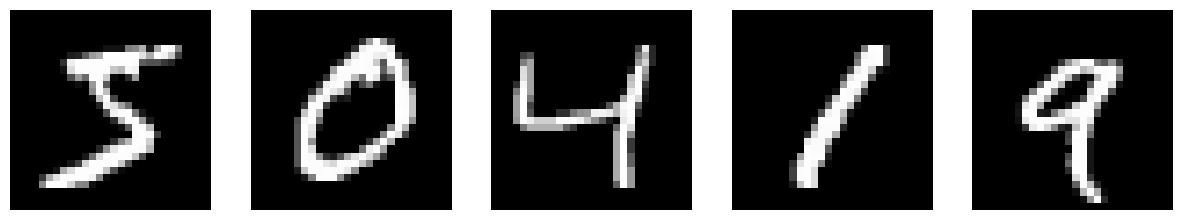

In [27]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(X_train[i], cmap='gray')
    ax[i].axis('off')

In [28]:
y_train[:5]

array([5, 0, 4, 1, 9], dtype=uint8)

Но давайте упростим себе задачу и возьмем для обучения только два класса, чтобы сделать задачу бинарной классификации.

In [29]:
idxs = np.where((y_train == 0) | (y_train == 1))
y_train = y_train[idxs]

In [30]:
X_train = X_train[idxs]

In [31]:
X_train.shape, y_train.shape

((12665, 28, 28), (12665,))

И тоже самое для теста.

In [32]:
idxs = np.where((y_test == 0) | (y_test == 1))
y_test = y_test[idxs]

X_test = X_test[idxs]

X_test.shape, y_test.shape

((2115, 28, 28), (2115,))

Убедимся, что теперь у нас только 0, либо 1.

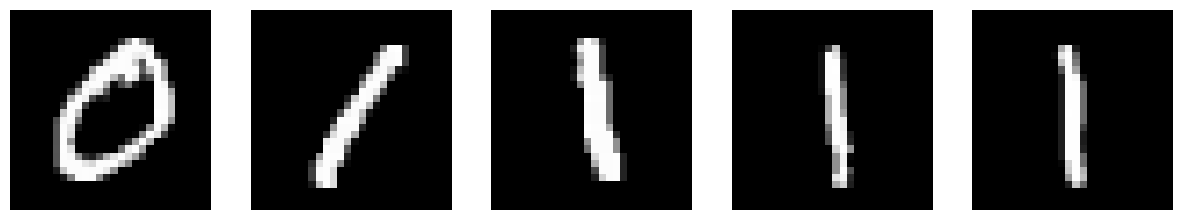

In [33]:
fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(X_train[i], cmap='gray')
    ax[i].axis('off')

In [34]:
y_train[:5]

array([0, 1, 1, 1, 1], dtype=uint8)

Нормируем данные, сейчас обойдемся без `MinMaxScaler` из `sklearn`, а воспользуемся делением на 255, т.к. сейчас изображения представлены пикселями в диапазоне от 0 до 255, а для нейросети комфортней обучаться на диапазоне от 0 до 1.

In [35]:
print(X_train.min(), X_train.max())

X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train.min(), X_train.max())

0 255
0.0 1.0


Так же нужно видоизменить метку класса, сейчас это лейблы 0 или 1, нужно преобразовать в бинарный вид.

Тем самым получаем 2 столбика, где первый - это метка является ли изображение 0 классом, а второй столбик - является ли изображение 1 классом.

In [36]:
from keras.utils import to_categorical

y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

y_train_cat[:5]

array([[1., 0.],
       [0., 1.],
       [0., 1.],
       [0., 1.],
       [0., 1.]])

А чтобы еще легче обучать сетку поменяем масштаб изображений, сейчас они 28 на 28, сделаем меньше, чтобы нейросеть была легче.

In [37]:
X_train[..., np.newaxis].shape

(12665, 28, 28, 1)

In [38]:
X_train[..., np.newaxis][..., 0].shape

(12665, 28, 28)

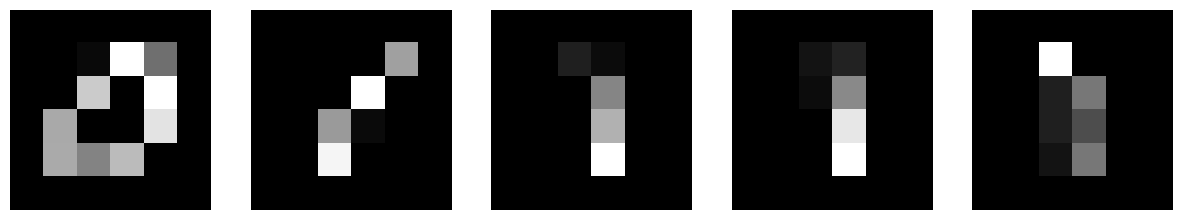

In [39]:
import matplotlib.pyplot as plt


X_train_resized = tf.image.resize(X_train[..., np.newaxis], (6, 6))[..., 0]
X_test_resized = tf.image.resize(X_test[..., np.newaxis], (6, 6))[..., 0]

fig, ax = plt.subplots(1, 5, figsize=(15, 10))

for i in range(5):
    ax[i].imshow(X_train_resized[i], cmap='gray')
    ax[i].axis('off')

Для того, что обучить нейронную сеть для любой задачи нужно ответить на три вопроса:
1. Какая архитектура сети?
2. Что оптимизируем?
3. Как обучаем?

### Какая архитектура сети

Создадим сеть еще сложнее.

Во-первых, на вход поступает изображение 6х6, нужно с ним что-то сделать, так как наша сетку пока не умеет работать с двумерным входом. Здесь нам поможет слой из `keras` `Flatten`, который вытягивает изображение в один вектор, была картинка 6x6, а станет вектором с размерностью 36.

Была матрица:

In [40]:
X_train_resized[0].numpy()

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.03594765, 0.9888889 , 0.42941174,
        0.        ],
       [0.        , 0.00228757, 0.7885626 , 0.        , 0.9901961 ,
        0.        ],
       [0.        , 0.65588236, 0.        , 0.        , 0.88235307,
        0.        ],
       [0.        , 0.66078436, 0.5088234 , 0.7235297 , 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        ]], dtype=float32)

In [41]:
X_train_resized[0].numpy().shape

(6, 6)

А теперь вектор:

In [42]:
X_train_resized[0].numpy().flatten()

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.03594765, 0.9888889 ,
       0.42941174, 0.        , 0.        , 0.00228757, 0.7885626 ,
       0.        , 0.9901961 , 0.        , 0.        , 0.65588236,
       0.        , 0.        , 0.88235307, 0.        , 0.        ,
       0.66078436, 0.5088234 , 0.7235297 , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        ], dtype=float32)

In [43]:
X_train_resized[0].numpy().flatten().shape

(36,)

Во-вторых, на выходе не что-то одно, а две вероятности быть или не быть определенным классом.

А значит на выходе имеем два нейрона, каждый из которых отвечает за класс.

<img src='https://drive.google.com/uc?id=1BQbGhOqu8rgv25QbyHe6qljE-koEm103' width=500>

В-третьих, на выходном слое нужно использовать другую функцию активации, а именно sigmoid, так как она позволяет решать задачу бинарной классификации очень хорошо.

In [44]:
from keras.layers import Flatten
tf.random.set_seed(9)

model = Sequential([
    Flatten(input_shape=(6, 6)),
    Dense(2, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 36)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 2)              │            74 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74 (296.00 B)

 Trainable params: 74 (296.00 B)

 Non-trainable params: 0 (0.00 B)

Считаем количество весов.

Для одного нейрона - 36 входов, плюс 1 bias. Для второго нейрона тоже самое.

А значит, (36 + 1) * 2 = 74 настраиваемых весов.

### Как оптимизируем

Возьмем тот же самый градиентный спуск со стохастикой.

In [45]:
model.compile(optimizer='sgd', loss='binary_crossentropy', metrics=['accuracy'])

In [46]:
%%time
model.fit(X_train_resized, y_train_cat, epochs=5)

Epoch 1/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8199 - loss: 0.5862
Epoch 2/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9420 - loss: 0.4559
Epoch 3/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9597 - loss: 0.3760
Epoch 4/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9656 - loss: 0.3226
Epoch 5/5
396/396 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9698 - loss: 0.2848
CPU times: user 4.94 s, sys: 292 ms, total: 5.23 s
Wall time: 4.27 s


Сеть обучается, ошибка падает, метрика становится лучше, всё замечательно.

Теперь проверим, а как модель работает на новых данных.

На выходе модель дает 2 вероятности:
1. Быть нулевым классом
2. Быть первым классом

Для выбранного объекта вероятность быть первым классом гораздо выше, чем вероятность быть нулевым классом.

In [47]:
print("Предсказание нейронной сети: ")
pred = model.predict(X_test_resized[:1])
pred

Предсказание нейронной сети: 


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step


array([[0.18868047, 0.77872324]], dtype=float32)

Для того, чтобы выдать финальную метку класса можем взять класс, где максимальная предсказанная вероятность.

In [48]:
pred_cls = pred.argmax()
pred_cls

np.int64(1)

Давайте проверим предсказание визуально.

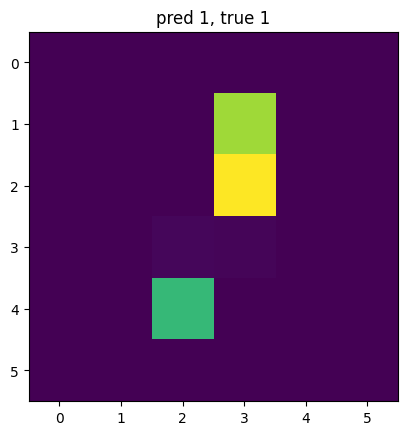

In [49]:
idx = 0
plt.imshow(X_test_resized[idx])
plt.title(f'pred {pred_cls}, true {y_test[idx]}');

А это как выглядило изображение до изменения размера.

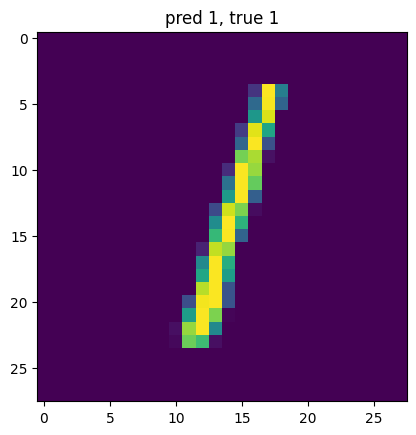

In [50]:
plt.imshow(X_test[idx])
plt.title(f'pred {pred_cls}, true {y_test[idx]}');

И проверимся на всех обучающих данных.

Делаем предсказания на всех тестовых объектах.

In [51]:
preds = model.predict(X_test_resized)
preds

67/67 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


array([[0.18868047, 0.77872324],
       [0.9023812 , 0.11277734],
       [0.15049967, 0.81597126],
       ...,
       [0.14027844, 0.8438358 ],
       [0.8528876 , 0.17981999],
       [0.14907636, 0.80755717]], dtype=float32)

И берем метку класса, где максимальная вероятность.

In [52]:
preds_cls = preds.argmax(axis=1)
preds_cls

array([1, 0, 1, ..., 1, 0, 1])

И можем посчитать метрику качества.

In [53]:
from sklearn.metrics import accuracy_score

print(f'test acc: {accuracy_score(y_test, preds_cls)*100:.2f}% ({(y_test == preds_cls).sum()} out of {y_test.shape[0]})')

test acc: 98.01% (2073 out of 2115)


Обучили сетку на задачу классификации.


## Алгоритм создания сети




1. Получаем выборку для обучения
    - масштабирование данных (*MinMaxScaler, StandardScaler, /255.0*)
    - Resize данных при необходимости
    - Для классификации нужно перевести метки классов в бинарное представление  

2. Создаем архитектуру
    - выбираем количество входов
    - выбираем количество слоев
    - выбираем количество выходных нейронов
    - выбираем функцию активации


3. Что нужно оптимизировать
    - выбор функции потерь
    - из стандартных и привычных
        - для регрессии - *MSE*
        - для классификации - *binary_crossentropy, categorical_crossentropy*
4. Как нужно оптимизировать
    - выбор оптимизатора
    - из стандартных и привычных: *sgd, adam*




5. Компиляция модели *.compile()*


6. Обучение модели *.fit()*


7. Проверка результатов